In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import shapely
from shapely.geometry import Point, LineString, Polygon
print(f"GeoPandas: {gpd.__version__}")
print(f"Shapely: {shapely.__version__}")
print("Environment working correctly")

GeoPandas: 1.1.3
Shapely: 2.1.2
Environment working correctly


In [6]:
from geodatasets import get_path

world = gpd.read_file(get_path("naturalearth.land"))
print(f"CRS: {world.crs}")
print(f"Shape: {world.shape}")
print(world.head())

CRS: EPSG:4326
Shape: (127, 4)
  featurecla  scalerank  min_zoom  \
0       Land          1       1.0   
1       Land          1       1.0   
2       Land          1       0.0   
3       Land          1       1.0   
4       Land          1       1.0   

                                            geometry  
0  POLYGON ((-59.57209 -80.04018, -59.86585 -80.5...  
1  POLYGON ((-159.20818 -79.49706, -161.1276 -79....  
2  POLYGON ((-45.15476 -78.04707, -43.92083 -78.4...  
3  POLYGON ((-121.21151 -73.50099, -119.91885 -73...  
4  POLYGON ((-125.55957 -73.48135, -124.03188 -73...  


In [8]:
import os
os.makedirs('../outputs', exist_ok=True)
print("outputs folder ready")

outputs folder ready


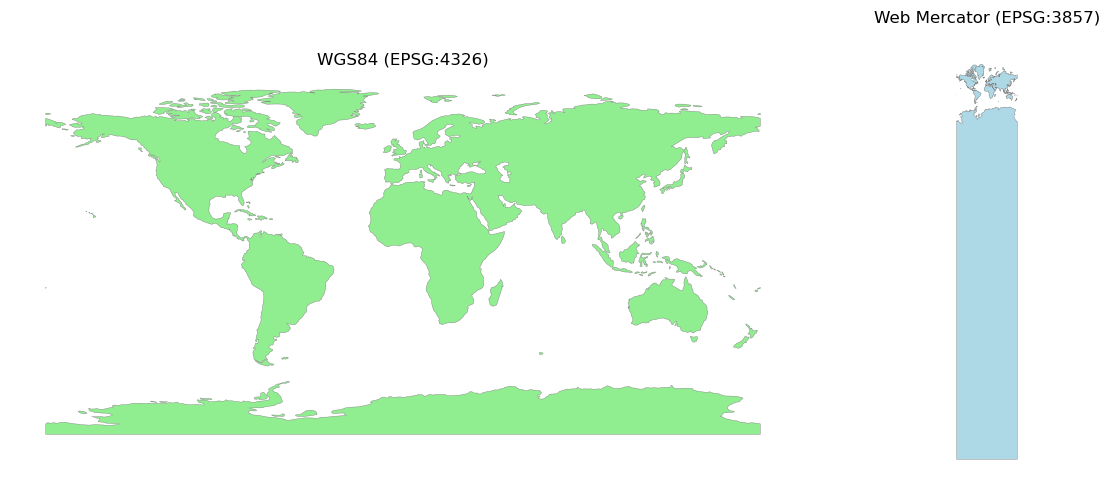

Map saved to outputs folder


In [9]:
# Cell 3 — reproject and plot
world_mercator = world.to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

world.plot(ax=axes[0], color='lightgreen', edgecolor='gray', linewidth=0.3)
axes[0].set_title("WGS84 (EPSG:4326)")
axes[0].set_axis_off()

world_mercator.plot(ax=axes[1], color='lightblue', edgecolor='gray', linewidth=0.3)
axes[1].set_title("Web Mercator (EPSG:3857)")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig('../outputs/01_projection_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Map saved to outputs folder")

Rows found for India: 1
India centroid (UTM 43N): POINT (980524.6271788331 2536985.3704928965)
Buffer area (km²): 4463388


C:\Users\sreeh\AppData\Local\Temp\ipykernel_22424\2598341358.py:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='lower left', fontsize=8)


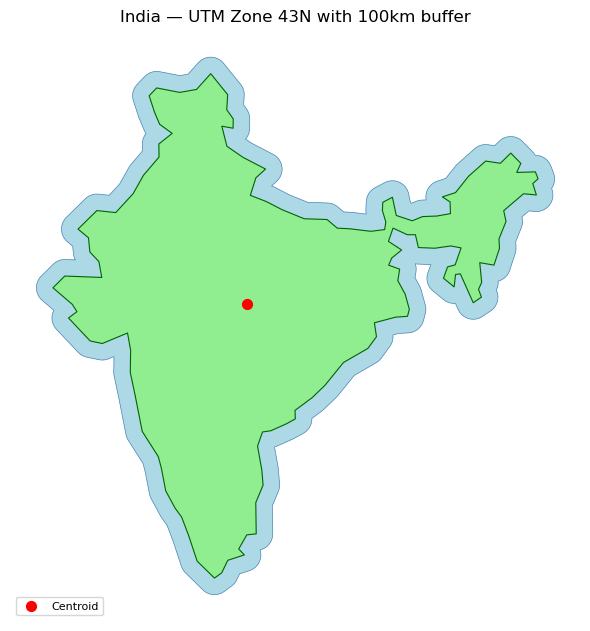

Saved: 02_india_buffer.png


In [10]:
# Cell 4 — your first spatial operations on real data
from geodatasets import get_path

# Load full countries dataset with attributes
world_full = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
)

# Filter to India
india = world_full[world_full['NAME'] == 'India'].copy()
print(f"Rows found for India: {len(india)}")

# Reproject to UTM Zone 43N (accurate for India/Kerala)
india_proj = india.to_crs(epsg=32643)

# Compute centroid
india_centroid = india_proj.geometry.centroid
print(f"India centroid (UTM 43N): {india_centroid.values[0]}")

# Buffer 100km around India boundary
india_buffer = india_proj.buffer(100000)
print(f"Buffer area (km²): {india_buffer.area.values[0] / 1e6:.0f}")

# Plot India + buffer
fig, ax = plt.subplots(figsize=(6, 8))
india_buffer.plot(ax=ax, color='lightblue', edgecolor='steelblue', linewidth=0.5, label='100km buffer')
india_proj.plot(ax=ax, color='lightgreen', edgecolor='darkgreen', linewidth=0.8, label='India boundary')
india_centroid.plot(ax=ax, color='red', markersize=50, zorder=5, label='Centroid')
ax.set_title("India — UTM Zone 43N with 100km buffer")
ax.set_axis_off()
ax.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/02_india_buffer.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_india_buffer.png")